# TP Final — Notebook 01: EDA y Limpieza
### Estimación de precios de alquiler para propietarios independientes

Aprendizaje Automático — 2026 Q1 · Trabajo Práctico Final (Entrega 2).

Este notebook cubre **análisis exploratorio, limpieza, análisis de *data leakage*,
ingeniería de features geográficas y separación train/test**. Es la primera etapa
del pipeline (regresión del precio mensual de alquiler) y deja exportado el dataset
procesado que consumen los notebooks `02_regresion` y `03_error_y_deploy`.

> Estructura espejo del pipeline de TP3, adaptado de clasificación a **regresión**.

## 0. Setup — verificación de dependencias y del dataset

Antes de cualquier análisis, el notebook **(a)** comprueba que estén instaladas todas
las librerías necesarias (e instala las que falten) y **(b)** comprueba que el dataset
esté descargado, descargándolo y descomprimiéndolo automáticamente si no está.

In [1]:
# --- 0.a Verificación / instalación de dependencias ---
import importlib, subprocess, sys

# nombre_pip -> nombre_import
REQUIRED = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
    "py7zr": "py7zr",
    "requests": "requests",
}

missing = []
for pip_name, import_name in REQUIRED.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Instalando dependencias faltantes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Listo. Reiniciá el kernel si algún import falla.")
else:
    print("Todas las dependencias están instaladas:", list(REQUIRED))


Todas las dependencias están instaladas: ['pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'scikit-learn', 'py7zr', 'requests']


In [2]:
# --- 0.b Verificación / descarga del dataset ---
from pathlib import Path
import py7zr, requests

DATA_DIR = Path("dataset")
DATA_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "apartments_for_rent_classified_100K.csv"
ZIP_PATH = DATA_DIR / "apartments.zip"
SEVENZ_PATH = DATA_DIR / "apartments_for_rent_classified_100K.7z"
UCI_URL = ("https://archive.ics.uci.edu/static/public/555/"
           "apartment+for+rent+classified.zip")

def ensure_dataset():
    if CSV_PATH.exists():
        print(f"Dataset OK: {CSV_PATH} ({CSV_PATH.stat().st_size/1e6:.1f} MB)")
        return
    print("Dataset no encontrado. Descargando desde UCI...")
    if not ZIP_PATH.exists():
        r = requests.get(UCI_URL, timeout=180)
        r.raise_for_status()
        ZIP_PATH.write_bytes(r.content)
        print(f"  Descargado zip: {ZIP_PATH.stat().st_size/1e6:.1f} MB")
    import zipfile
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)              # contiene los .7z
    with py7zr.SevenZipFile(SEVENZ_PATH, "r") as z:
        z.extractall(DATA_DIR)             # extrae el CSV 100K
    assert CSV_PATH.exists(), "No se pudo extraer el CSV"
    print(f"Dataset listo: {CSV_PATH} ({CSV_PATH.stat().st_size/1e6:.1f} MB)")

ensure_dataset()


Dataset OK: dataset/apartments_for_rent_classified_100K.csv (102.2 MB)


In [3]:
# --- Imports comunes y configuración ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
PROC_DIR = Path("data/processed"); PROC_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)


## 1. Alcance del problema (scope)

A partir de las correcciones de la Entrega 1, **acotamos el scope** para que el modelo
sea defendible:

| Dimensión | Definición |
|---|---|
| **Qué** | Estimar un *precio de listado mensual de referencia* + un **rango** (intervalo de confianza). |
| **Quién** | Propietario independiente / pequeño inversor publicando una unidad. |
| **Cuándo** | Al fijar el precio inicial del aviso (no re-tasación dinámica). |
| **Dónde** | **Apartamentos** en EE.UU., en **ciudades con suficientes comparables** en los datos. |
| **Por qué** | Dar un número objetivo y reducir dependencia de intermediarios. |

**Filtros de alcance (derivan limitaciones):**
- Sólo `category = apartment` (casas / comerciales quedan fuera → limitación explícita).
- Sólo `price_type = Monthly` y `currency = USD`.
- Sólo ciudades con `>= MIN_LISTINGS` avisos (sin comparables suficientes, no predecimos).

**Limitaciones que se comunican:** datos de 2019 (nivel de precios desactualizado, sin
estacionalidad ni post-pandemia), sesgo geográfico, sin estado de conservación ni
regulaciones locales.

In [4]:
MIN_LISTINGS = 200   # mínimo de avisos por ciudad para entrar en el scope
KNN_K = 10           # vecinos para la feature de precio local


## 2. Carga del dataset

In [5]:
df = pd.read_csv(CSV_PATH, sep=";", encoding="latin-1", low_memory=False)
print("Shape crudo:", df.shape)
print("Columnas:", list(df.columns))
df.head(3)


Shape crudo: (99492, 22)
Columnas: ['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332


In [6]:
df.dtypes


id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price            float64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

## 3. Variable objetivo (`price`)

El precio es el target de la regresión. Esperamos una distribución asimétrica con outliers
(precios extremos), lo que motivará trabajar en escala logarítmica y/o capar outliers.

count    99491.0
mean      1527.1
std        904.2
min        100.0
25%       1013.0
50%       1350.0
75%       1795.0
max      52500.0
Name: price, dtype: float64


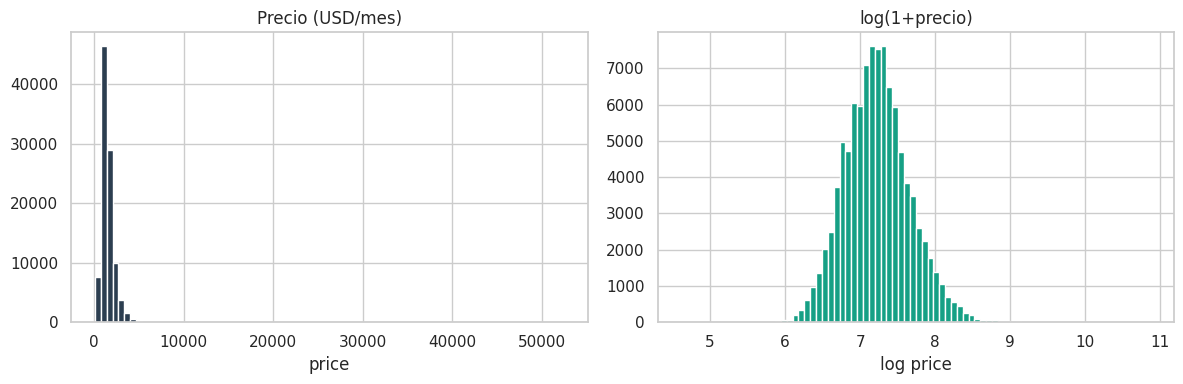

In [7]:
price_num = pd.to_numeric(df["price"], errors="coerce")
print(price_num.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(price_num.dropna(), bins=80, color="#2c3e50")
ax[0].set_title("Precio (USD/mes)"); ax[0].set_xlabel("price")
ax[1].hist(np.log1p(price_num.dropna()), bins=80, color="#16a085")
ax[1].set_title("log(1+precio)"); ax[1].set_xlabel("log price")
plt.tight_layout(); plt.savefig(OUT_DIR/"01_distribucion_precios.png", dpi=110); plt.show()


## 4. Limpieza y filtro de alcance

Aplicamos los filtros de la sección 1 y registramos cuántas filas sobreviven en cada paso
(para poder justificar el universo final).

In [8]:
def step(df_, msg):
    print(f"{msg:<45} filas = {len(df_):>6}")
    return df_

d = df.copy()
step(d, "crudo")

# tipos numéricos
for c in ["price", "square_feet", "bedrooms", "bathrooms", "latitude", "longitude"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# --- filtros de alcance ---
d = step(d[d["category"] == "housing/rent/apartment"], "category == apartment")
d = step(d[d["price_type"] == "Monthly"], "price_type == Monthly")
d = step(d[d["currency"] == "USD"], "currency == USD")

# requeridos no nulos
req = ["price", "square_feet", "bedrooms", "bathrooms", "latitude", "longitude", "cityname", "state"]
d = step(d.dropna(subset=req), "drop NA en columnas requeridas")

# rangos plausibles (documentado, no agresivo): apartamentos reales
d = step(d[d["price"].between(200, 10000)], "price en [200, 10000]")
d = step(d[d["square_feet"].between(120, 6000)], "square_feet en [120, 6000]")
d = step(d[d["bedrooms"].between(0, 6)], "bedrooms en [0, 6]")
d = step(d[d["bathrooms"].between(0.5, 6)], "bathrooms en [0.5, 6]")

# ciudades con suficientes comparables
city_key = d["state"] + " | " + d["cityname"]
counts = city_key.value_counts()
keep_cities = counts[counts >= MIN_LISTINGS].index
d = d.assign(city_key=city_key)
d = step(d[d["city_key"].isin(keep_cities)], f"ciudades con >= {MIN_LISTINGS} avisos")

print(f"\nCiudades en scope: {d['city_key'].nunique()}  | filas finales: {len(d)}")


crudo                                         filas =  99492
category == apartment                         filas =  99431
price_type == Monthly                         filas =  99427
currency == USD                               filas =  99427
drop NA en columnas requeridas                filas =  98944
price en [200, 10000]                         filas =  98872
square_feet en [120, 6000]                    filas =  98865
bedrooms en [0, 6]                            filas =  98858
bathrooms en [0.5, 6]                         filas =  98858
ciudades con >= 200 avisos                    filas =  48826

Ciudades en scope: 101  | filas finales: 48826


## 5. Análisis de *data leakage*

Riesgo central en este problema: **features que filtran el target**.

- **`price_display`** → es el `price` formateado como string (`"$1,350"`). **Se elimina.**
- **`price_type`, `currency`** → constantes tras el filtro. No aportan, se eliminan.
- **`address`** → 92% faltante y texto libre. Se elimina.
- **Agregados por ubicación** (mediana de precio por ciudad, precio de vecinos KNN):
  **NO se calculan sobre todo el dataset**. Se calculan **sólo con el split de
  entrenamiento** y se aplican a test (secciones 8–9). Calcularlos antes del split sería
  *leakage*: el precio de test influiría en sus propias features.
- **`time`** → timestamp de publicación; válido como feature y útil para monitoreo de drift.

In [9]:
drop_cols = ["price_display", "price_type", "currency", "address", "id", "title", "body"]
d = d.drop(columns=[c for c in drop_cols if c in d.columns])
d["time"] = pd.to_datetime(d["time"], unit="s")
print("Columnas tras drop:", list(d.columns))
print("Rango temporal:", d["time"].min(), "->", d["time"].max())


Columnas tras drop: ['category', 'amenities', 'bathrooms', 'bedrooms', 'fee', 'has_photo', 'pets_allowed', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time', 'city_key']
Rango temporal: 2018-12-07 09:20:18 -> 2019-12-26 11:42:38


## 6. EDA visual (sobre el universo en scope)

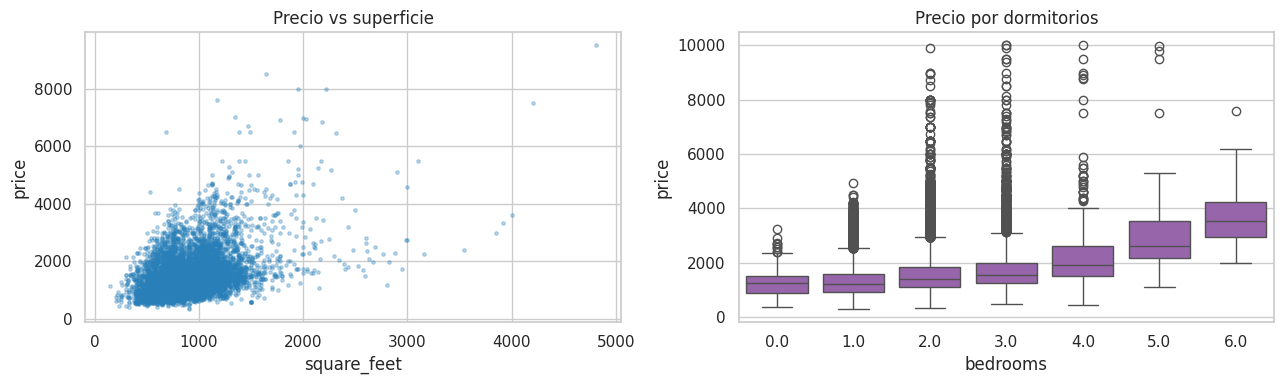

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
s = d.sample(min(8000, len(d)), random_state=RANDOM_STATE)
ax[0].scatter(s["square_feet"], s["price"], s=6, alpha=0.3, color="#2980b9")
ax[0].set_xlabel("square_feet"); ax[0].set_ylabel("price"); ax[0].set_title("Precio vs superficie")
sns.boxplot(data=d, x="bedrooms", y="price", ax=ax[1], color="#9b59b6")
ax[1].set_title("Precio por dormitorios")
plt.tight_layout(); plt.savefig(OUT_DIR/"02_precio_features.png", dpi=110); plt.show()


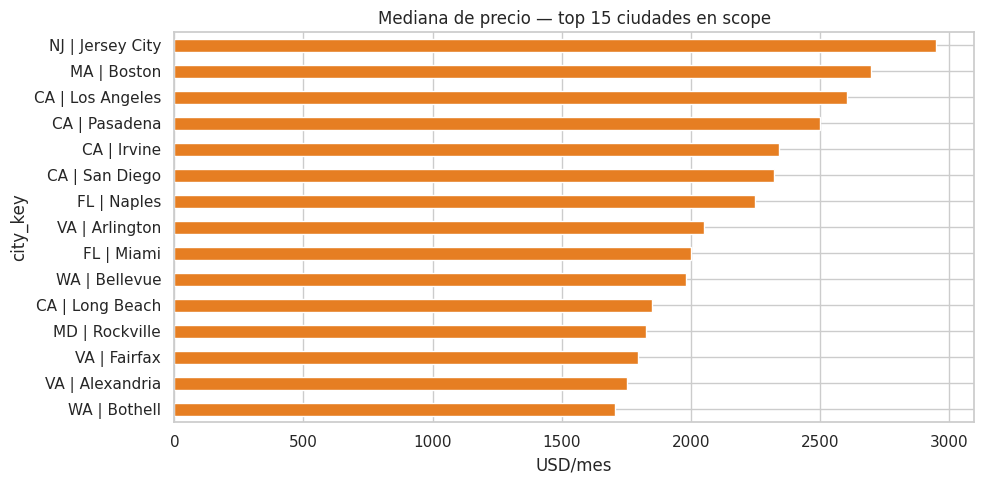

In [11]:
top = d.groupby("city_key")["price"].median().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
top.iloc[::-1].plot.barh(ax=ax, color="#e67e22")
ax.set_title("Mediana de precio — top 15 ciudades en scope"); ax.set_xlabel("USD/mes")
plt.tight_layout(); plt.savefig(OUT_DIR/"03_precio_por_ciudad.png", dpi=110); plt.show()


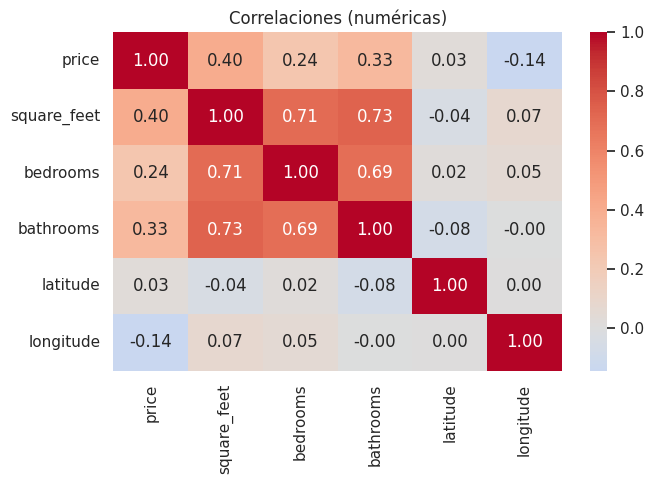

In [12]:
num = ["price", "square_feet", "bedrooms", "bathrooms", "latitude", "longitude"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(d[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlaciones (numéricas)")
plt.tight_layout(); plt.savefig(OUT_DIR/"04_correlaciones.png", dpi=110); plt.show()


## 7. Features no dependientes de ubicación

Features que se pueden construir fila a fila sin riesgo de leakage (no usan el target ni
otras filas):

- `n_amenities`, `has_amenities` a partir de la lista `amenities`.
- `has_photo`, `fee` → binarias.
- **`pets_allowed`**: 61% faltante. Preparamos las **dos versiones para la ablación**
  pedida en la corrección:
  - `pets_filled_no`: faltante → `"no"` (se asume que no admite mascotas).
  - `pets_known`: flag 1/0 de si el dato existe (versión "unknown").

In [13]:
d["n_amenities"] = d["amenities"].fillna("").apply(lambda s: 0 if s == "" else len(str(s).split(",")))
d["has_amenities"] = (d["n_amenities"] > 0).astype(int)
d["has_photo_bin"] = (d["has_photo"].astype(str).str.lower() == "thumbnail").astype(int)
d["fee_bin"] = (d["fee"].astype(str).str.lower() == "yes").astype(int)

# pets: dos representaciones para ablación en NB2
d["pets_known"] = d["pets_allowed"].notna().astype(int)
d["pets_filled_no"] = d["pets_allowed"].fillna("no")
print(d[["n_amenities", "has_amenities", "has_photo_bin", "fee_bin", "pets_known"]].describe().round(2))
print(d["pets_filled_no"].value_counts().head())


       n_amenities  has_amenities  has_photo_bin   fee_bin  pets_known
count     48826.00       48826.00       48826.00  48826.00    48826.00
mean          3.67           0.84           0.35      0.00        0.40
std           3.32           0.37           0.48      0.04        0.49
min           0.00           0.00           0.00      0.00        0.00
25%           1.00           1.00           0.00      0.00        0.00
50%           3.00           1.00           0.00      0.00        0.00
75%           5.00           1.00           1.00      0.00        1.00
max          18.00           1.00           1.00      1.00        1.00
pets_filled_no
no           29376
Cats,Dogs    18604
Cats           814
Dogs            32
Name: count, dtype: int64


## 8. Split train / test (antes de cualquier feature con agregados)

Hacemos el split **ahora**, para que las features dependientes de ubicación se ajusten
únicamente con `train`. Split 80/20 **estratificado por precio** (deciles): garantiza que
tanto train como test cubran todo el rango de precios (evita que los caros/baratos queden
concentrados en un solo lado). Estratificamos por el **target (precio)** y no por m² porque
es la variable que el modelo predice.

In [14]:
from sklearn.model_selection import train_test_split

# Estratificamos por PRECIO (target) discretizado en deciles: así train y test
# quedan balanceados en todo el rango de precios (baratos y caros bien representados).
# El precio es el objetivo de la regresión, por eso balanceamos por él y no por m2.
price_bins = pd.qcut(d["price"], q=10, labels=False, duplicates="drop")
train, test = train_test_split(d, test_size=0.20, random_state=RANDOM_STATE,
                               stratify=price_bins)
print("train:", train.shape, "| test:", test.shape)
print("Balance por decil de precio (train vs test):")
print(pd.concat([train["price"].describe(), test["price"].describe()], axis=1,
                keys=["train", "test"]).round(0))

train: (39060, 22) | test: (9766, 22)
Balance por decil de precio (train vs test):
         train    test
count  39060.0  9766.0
mean    1502.0  1504.0
std      743.0   744.0
min      299.0   313.0
25%     1021.0  1020.0
50%     1337.0  1337.0
75%     1749.0  1750.0
max    10000.0  9500.0


## 9. Features dependientes de ubicación (ajustadas SOLO en train)

Acá está el foco que pidió la corrección sobre lat/lon. Construimos, **sin leakage**:

1. **`dist_city_center`**: distancia (km) al centroide de su ciudad. El centroide se
   calcula con las coordenadas de **train**.
2. **`knn_price`**: mediana de precio de los `KNN_K` avisos de **train** más cercanos
   geográficamente (para filas de train se excluye la propia fila).
3. **`city_price_median` / `city_price_mean`**: estadísticos de precio por ciudad
   calculados en **train**; ciudades no vistas → mediana global de train.

In [15]:
from sklearn.neighbors import BallTree

EARTH_KM = 6371.0

# 1) centroide de ciudad (train) + distancia haversine
centroids = train.groupby("city_key")[["latitude", "longitude"]].mean()
def add_dist(df_):
    c = centroids.reindex(df_["city_key"]).to_numpy()
    lat1, lon1 = np.radians(df_["latitude"].to_numpy()), np.radians(df_["longitude"].to_numpy())
    lat2, lon2 = np.radians(c[:, 0]), np.radians(c[:, 1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_KM * 2 * np.arcsin(np.sqrt(a))
train = train.assign(dist_city_center=add_dist(train))
test = test.assign(dist_city_center=add_dist(test))

# 2) knn_price con BallTree (haversine) ajustado en train
coords_tr = np.radians(train[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_tr, metric="haversine")
price_tr = train["price"].to_numpy()

def knn_price(df_, is_train):
    coords = np.radians(df_[["latitude", "longitude"]].to_numpy())
    k = KNN_K + 1 if is_train else KNN_K          # +1 para excluir la propia fila en train
    _, idx = tree.query(coords, k=k)
    if is_train:
        idx = idx[:, 1:]                          # descartar self
    return np.median(price_tr[idx], axis=1)

train = train.assign(knn_price=knn_price(train, True))
test = test.assign(knn_price=knn_price(test, False))

# 3) estadísticos de ciudad (train)
g = train.groupby("city_key")["price"]
city_med, city_mean = g.median(), g.mean()
glob_med = train["price"].median()
for part in ("train", "test"):
    pass
train["city_price_median"] = train["city_key"].map(city_med).fillna(glob_med)
train["city_price_mean"]   = train["city_key"].map(city_mean).fillna(glob_med)
test["city_price_median"]  = test["city_key"].map(city_med).fillna(glob_med)
test["city_price_mean"]    = test["city_key"].map(city_mean).fillna(glob_med)

print(train[["dist_city_center", "knn_price", "city_price_median"]].describe().round(1))


       dist_city_center  knn_price  city_price_median
count           39060.0    39060.0            39060.0
mean                6.9     1449.6             1413.1
std                 5.4      581.2              486.7
min                 0.0      550.0              699.0
25%                 2.8     1049.5             1075.0
50%                 5.5     1332.5             1252.0
75%                 9.4     1660.0             1502.5
max                43.5     6250.0             2939.0


## 10. Exportar dataset procesado

Guardamos `train.csv` / `test.csv` con las columnas que usarán los próximos notebooks,
manteniendo **ambas** representaciones de `pets_allowed` para la ablación.

In [16]:
KEEP = [
    "price",                                            # target
    "square_feet", "bedrooms", "bathrooms",             # estructurales
    "latitude", "longitude", "dist_city_center",        # geo
    "knn_price", "city_price_median", "city_price_mean",# geo agregados (train-only)
    "n_amenities", "has_amenities", "has_photo_bin", "fee_bin",
    "pets_filled_no", "pets_known",                     # ablación pets
    "cityname", "state", "city_key", "time",            # contexto / encoding en NB2
]
train_out, test_out = train[KEEP].copy(), test[KEEP].copy()
train_out.to_csv(PROC_DIR/"train.csv", index=False)
test_out.to_csv(PROC_DIR/"test.csv", index=False)

with open(PROC_DIR/"feature_notes.txt", "w") as f:
    f.write("Features geográficas (knn_price, city_price_*, dist_city_center) y stats "
            "se ajustaron SOLO con train para evitar leakage.\n")
    f.write(f"MIN_LISTINGS={MIN_LISTINGS}, KNN_K={KNN_K}, RANDOM_STATE={RANDOM_STATE}\n")
    f.write("pets: 'pets_filled_no' (NA->'no') vs 'pets_known' (flag) -> ablación en NB2.\n")

print("Exportado:", PROC_DIR/"train.csv", train_out.shape, "|", PROC_DIR/"test.csv", test_out.shape)


Exportado: data/processed/train.csv (39060, 20) | data/processed/test.csv (9766, 20)


## 11. Conclusiones de esta etapa

- Universo acotado a **apartamentos mensuales en USD, en ciudades con comparables
  suficientes** → scope defendible y limitaciones explícitas.
- **Leakage controlado**: se eliminó `price_display` y los agregados por ubicación se
  calculan **sólo en train**.
- Se construyeron las **features geográficas** (distancia al centro, precio KNN, stats por
  ciudad) que serán protagonistas del modelo.
- `pets_allowed` queda preparado en **dos versiones** para la ablación.

**Siguiente:** `02_regresion.ipynb` — baseline, modelos, métricas (MAE/RMSE/MAPE) e
intervalos de predicción (rango + mejor estimación).